In [38]:
import numpy as np
import matplotlib.pylab as plt
import sys
sys.path.append("..")

### 1D nodal --> modal

nodal inverse max err: 6.661338147750939e-16
nodal inverse rel err: 2.2110020656140235e-16
grid eval max err    : 6.661338147750939e-16
grid eval rel err    : 2.2110020656140235e-16


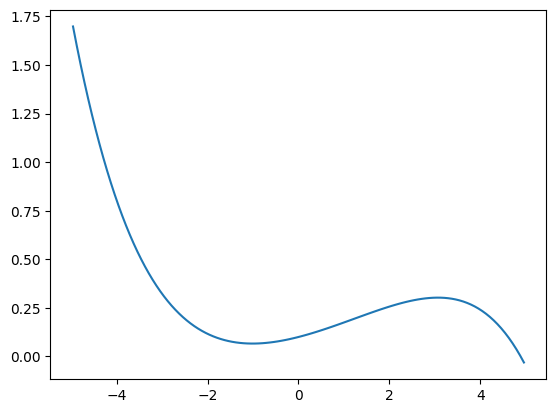

In [39]:
from src.research_utils_1d import(
    build_mesh_1d, 
    local_cell_center_nodes_1d,
    build_grid_from_local_nodes_1d, 
    nodal_to_modal_1d, 
    modal_to_nodal_1d, 
    eval_dg_modal_local_nodes_1d, 
)

def exact_poly1d_scaled(x, degree=4, xlim=(-1,1)):
    x = np.asarray(x)
    
    # map to [-1,1]
    xhat = 2*(x - xlim[0]) / (xlim[1] - xlim[0]) - 1
    
    poly = 0.1 * np.ones_like(xhat)
    if degree >= 1:
        poly += 0.3*xhat
    if degree >= 2:
        poly += 0.5*xhat**2
    if degree >= 3:
        poly += -0.7*xhat**3
    if degree >= 4:
        poly += 0.25*xhat**4
    if degree >= 5:
        poly += -0.5*xhat**5
    
    return poly


##### Roundtrip check for DG #####
### setup
xmin, xmax = -5, 5
xlim = (xmin, xmax)

# DG stuff
K = 24
p = 4
order = p + 1
N = K * order

# Build mesh
mesh = build_mesh_1d(K=K, domain=xlim)

# Build signal grid
n_eval = order      # p + 1 eval points per element
nodes = local_cell_center_nodes_1d(nloc=n_eval)
grid, grid_blocks = build_grid_from_local_nodes_1d(mesh, eval_nodes=nodes, return_blocks=True)

# exact data on grid
poly_deg = p + 1
exact_data = exact_poly1d_scaled(x=grid, degree=poly_deg, xlim=xlim)

# exact data on nodal representation
Unode = exact_poly1d_scaled(x=grid_blocks, degree=poly_deg, xlim=xlim)

# DG representation (modal)
dg = nodal_to_modal_1d(Unode=Unode, mesh=mesh, p=p)

arr_rec1, Ueval1 = modal_to_nodal_1d(dg, return_blocks=True)

arr_rec2, Ueval2 = eval_dg_modal_local_nodes_1d(dg, eval_nodes=nodes, return_blocks=True)


print("nodal inverse max err:", np.max(np.abs(arr_rec1 - exact_data)))
print("nodal inverse rel err:", np.linalg.norm(arr_rec1 - exact_data) / np.linalg.norm(exact_data))

print("grid eval max err    :", np.max(np.abs(arr_rec2 - exact_data)))
print("grid eval rel err    :", np.linalg.norm(arr_rec2 - exact_data) / np.linalg.norm(exact_data))

plt.plot(grid, exact_data)


In [40]:
from src.research_utils_1d import (
    apply_siac_modal_dg_local_nodes_1d, 
    trim_valid_siac_region_1d
)

# Standard moments and BSorder choices are moments = 2p + 1 (becomes 2p here for symmetric SIAC), and BSorder = p + 1 (e.g., moments = 4, BSorder = 3)
moments = 4     # Note (extreme case): If p = k, and k even, and poly_deg = k + 1. choosing moments = k (symmetric SIAC -> reproduces k + 1 polynomial), and associated BSorder, then this error should be tiny
BSorder = 3     # Note: otherwise, choosing p = k and poly_deg = k, k even, and moments = k, with associated BSorder, then error should be machine precision
arr_rec3 = apply_siac_modal_dg_local_nodes_1d(dg, moments=moments, BSorder=BSorder, eval_nodes=nodes)

# Trim to valid SIAC region (disregard boundary artifacts)
arr_rec3_trim = trim_valid_siac_region_1d(arr=arr_rec3, n_eval=n_eval, moments=moments, BSorder=BSorder, safety_pad=False)
exact_data_trim = trim_valid_siac_region_1d(arr=exact_data, n_eval=n_eval, moments=moments, BSorder=BSorder, safety_pad=False)

print("SIAC max err (internal):", np.max(np.abs(arr_rec3_trim - exact_data_trim)))
print("SIAC rel err (internal):", np.linalg.norm(arr_rec3_trim - exact_data_trim) / np.linalg.norm(exact_data_trim))


SIAC max err (internal): 1.6653345369377348e-16
SIAC rel err (internal): 2.5852962755786536e-16


### Pointwise error on fine grid

In [41]:
# -----------------------------
# 1. Problem / domain setup
# -----------------------------
xmin, xmax = -5, 5
xlim = (xmin, xmax)

# DG polynomial degree
p = 5
order = p + 1

# DG mesh resolution
K = 16
N = K * order

# SIAC parameters
moments = 4
BSorder = 3

# exact polynomial degree for testing
poly_deg = 5

# -----------------------------
# 2. Build mesh and original image grid
# -----------------------------
orig_nodes = local_cell_center_nodes_1d(nloc=order)
orig_n_eval = order

mesh = build_mesh_1d(K, domain=xlim)
grid, grid_blocks = build_grid_from_local_nodes_1d(mesh, eval_nodes=orig_nodes, return_blocks=True)

exact_data = exact_poly1d_scaled(x=grid, degree=poly_deg, xlim=xlim)
Unode = exact_poly1d_scaled(x=grid_blocks, degree=poly_deg, xlim=xlim)

# -----------------------------
# 3. Build DG representation
# -----------------------------
dg = nodal_to_modal_1d(Unode, mesh=mesh, p=p)

# -----------------------------
# 4. Fine local nodes per element
# -----------------------------
n_eval = 8 * order
nodes_fine = local_cell_center_nodes_1d(n_eval)

assert int(n_eval) == int(len(nodes_fine)), "ValueError: length of nodes_fine does not equal number of fine evaluation points (n_eval)"
# -----------------------------
# 5. Build global fine grid
# -----------------------------
grid_fine = build_grid_from_local_nodes_1d(mesh, eval_nodes=nodes_fine, return_blocks=False)

# -----------------------------
# 6. Evaluate exact, DG, SIAC
# -----------------------------

U_exact = exact_poly1d_scaled(x=grid_fine, degree=poly_deg, xlim=xlim)

U_dg = eval_dg_modal_local_nodes_1d(dg, eval_nodes=nodes_fine)

U_siac = apply_siac_modal_dg_local_nodes_1d(dg, moments=moments, BSorder=BSorder, eval_nodes=nodes_fine)

# -----------------------------
# 7. Trim interior for SIAC comparison
# -----------------------------

exact_trim = trim_valid_siac_region_1d(arr=U_exact, n_eval=n_eval, moments=moments, BSorder=BSorder)

dg_trim = trim_valid_siac_region_1d(arr=U_dg, n_eval=n_eval, moments=moments, BSorder=BSorder)

siac_trim = trim_valid_siac_region_1d(arr=U_siac, n_eval=n_eval, moments=moments, BSorder=BSorder)

# -----------------------------
# 8. Errors (interior only comparison)
# -----------------------------
err_dg = dg_trim - exact_trim
err_siac = siac_trim - exact_trim

print("DG max err   :", np.max(np.abs(err_dg)))
print("DG rel err   :", np.linalg.norm(err_dg) / np.linalg.norm(exact_trim))

print("SIAC max err :", np.max(np.abs(err_siac)))
print("SIAC rel err :", np.linalg.norm(err_siac) / np.linalg.norm(exact_trim))


DG max err   : 6.938893903907228e-16
DG rel err   : 5.501490557327855e-16
SIAC max err : 1.942890293094024e-16
SIAC rel err : 3.418547070984092e-16


### Convergence study

In [42]:

def add_noise_to_data(exact_data, h, p, sigma_scale=1.0, seed=62):
    """
    Add noise to the exact function exact_func.
    h - element spacing
    p - DG polynomial basis degree
    basic: noise of level h**(p+1), h = sqrt(hx^2 + hy^2), characteristic length of mesh
    """
    rng = np.random.default_rng(seed)
    
    pw = p+1
    sigma = h ** pw
    
    noise = rng.standard_normal(exact_data.shape) * sigma * sigma_scale
    
    # print(f"[noise] h={h:.3e}, sigma={sigma:.3e} (h^{pw})")
    # rel_noise = np.linalg.norm(noise) / np.linalg.norm(exact_data)
    # print(f"[rel.noise] rel_noise={rel_noise:.3e}")
    
    return exact_data + noise


In [43]:
def convergence_study_dg_siac_1d(
    exact_fun,
    K_values,
    p,
    xlim=(-1, 1),
    fine_factor=8,
    moments=None,
    BSorder=None, 
    quad_order=None,
    add_noise=False,
    exact_fun_kwargs=None,
):
    if moments is None:
        moments = 2 * p
    if BSorder is None:
        BSorder = p + 1
    if exact_fun_kwargs is None:
        exact_fun_kwargs = {}

    K_values = np.asarray(K_values, dtype=int)

    K_list = []
    h_list = []

    dg_max_list = []
    dg_rel_l2_list = []

    siac_max_list = []
    siac_rel_l2_list = []

    # Check refinement pattern
    assert np.all(K_values[1:] == 2 * K_values[:-1]), \
        "K_values must double each step, e.g. [8,16,32,64]"

    Kmax = np.max(K_values)

    # Fixed global evaluation resolution per direction
    N_eval_global = Kmax * fine_factor * (p + 1)

    nodes = local_cell_center_nodes_1d(p + 1)
    n_eval = int(len(nodes))
    for K in K_values:
        N = K * (p + 1)

        # Original image grid
        mesh = build_mesh_1d(K, domain=xlim)
        grid, grid_blocks = build_grid_from_local_nodes_1d(mesh, nodes, return_blocks=True)
        # Characteristic mesh size
        h = mesh["h"]
        
        # Exact data on original grid (nodal)
        Unode = exact_fun(x=grid_blocks, xlim=xlim, **exact_fun_kwargs)
        
        # Add optional noise
        if add_noise == True:
            Unode = add_noise_to_data(exact_data=Unode, h=h, p=p)

        # Build DG representation
        dg = nodal_to_modal_1d(Unode, mesh, p)

        # Number of evaluation points per element
        assert N_eval_global % K == 0, \
            f"N_eval_global={N_eval_global} must be divisible by K={K}"

        n_eval_fine = int(N_eval_global // K)
        nodes_fine = local_cell_center_nodes_1d(n_eval_fine)

        # Global fine grid
        grid_fine = build_grid_from_local_nodes_1d(mesh, nodes_fine, return_blocks=False)

        # Exact, DG, and SIAC on same fine grid
        exact_fine = exact_fun(x=grid_fine, xlim=xlim, **exact_fun_kwargs)
        dg_fine = eval_dg_modal_local_nodes_1d(dg, eval_nodes=nodes_fine, return_blocks=False)
        siac_fine = apply_siac_modal_dg_local_nodes_1d(dg, moments=moments, BSorder=BSorder, eval_nodes=nodes_fine, quad_order=quad_order)

        # Trim valid SIAC interior
        exact_trim, trim = trim_valid_siac_region_1d(
            arr=exact_fine,
            n_eval=n_eval_fine,
            moments=moments,
            BSorder=BSorder,
            safety_pad=False,
            return_trim=True
        )
        dg_trim = trim_valid_siac_region_1d(
            arr=dg_fine,
            n_eval=n_eval_fine,
            moments=moments,
            BSorder=BSorder,
            safety_pad=False
        )
        siac_trim = trim_valid_siac_region_1d(
            arr=siac_fine,
            n_eval=n_eval_fine,
            moments=moments,
            BSorder=BSorder,
            safety_pad=False,
        )

        # Errors
        err_dg = dg_trim - exact_trim
        err_siac = siac_trim - exact_trim

        dg_max = np.max(np.abs(err_dg))
        dg_rel_l2 = np.linalg.norm(err_dg) / np.linalg.norm(exact_trim)

        siac_max = np.max(np.abs(err_siac))
        siac_rel_l2 = np.linalg.norm(err_siac) / np.linalg.norm(exact_trim)

        # Store
        K_list.append(K)
        h_list.append(h)

        dg_max_list.append(dg_max)
        dg_rel_l2_list.append(dg_rel_l2)

        siac_max_list.append(siac_max)
        siac_rel_l2_list.append(siac_rel_l2)

    return {
        "K": np.asarray(K_list, dtype=int),
        "h": np.asarray(h_list, dtype=float),
        "dg_max": np.asarray(dg_max_list, dtype=float),
        "dg_rel_l2": np.asarray(dg_rel_l2_list, dtype=float),
        "siac_max": np.asarray(siac_max_list, dtype=float),
        "siac_rel_l2": np.asarray(siac_rel_l2_list, dtype=float),
    }

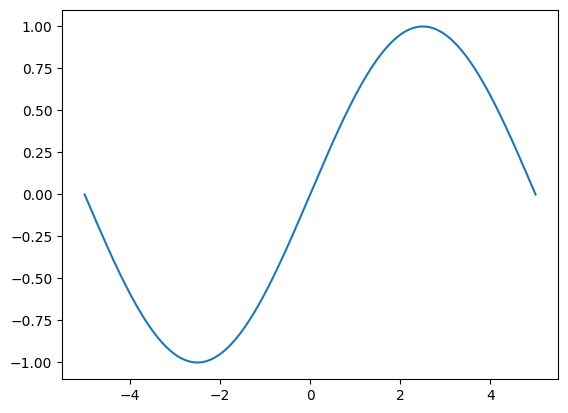

In [44]:
def exact_bumped_trig1d(x, xlim=(-1, 1), alpha=3.0):
    x = np.asarray(x, dtype=float)

    xhat = 2 * (x - xlim[0]) / (xlim[1] - xlim[0]) - 1.0
    return (
        2*np.exp(-alpha * xhat**2)
        + (0.3 * np.cos(7 * np.pi * xhat))
    )

def exact_trig1d(x, xlim=(-1, 1)):
    x = np.asarray(x, dtype=float)
    
    xhat = 2 * (x - xlim[0]) / (xlim[1] - xlim[0]) - 1.0
    return np.sin(np.pi * xhat)


xlim = (-5, 5)
x_test = np.linspace(xlim[0], xlim[1], 201)

plt.plot(x_test, exact_trig1d(x_test, xlim))


In [45]:

# DG stuff
p = 2

# Postprocessor
moments = 2 * p
BSorder = p + 1

# grid information
xlim = (-1, 1)

# convergence information
halfker = int(np.ceil(moments + BSorder)/2)
pad = halfker + 1

start_K = max(16, 4 * pad)
K_values = start_K * 2**np.arange(10)
fine_factor = 20


quad_order = 2*p+4

results = convergence_study_dg_siac_1d(
    exact_fun=exact_trig1d, 
    K_values=K_values, 
    p=p,
    xlim=xlim,
    fine_factor=fine_factor, 
    moments=moments, 
    BSorder=BSorder, 
    quad_order=quad_order, 
    add_noise=True
)


DG rates   : [3.18696809 3.04066945 2.89559742 2.94749624 2.97768915 2.97518083
 3.00941177 2.98869578 3.00212554]
SIAC rates : [2.75958633 3.14458238 2.97633892 2.99325232 2.9242921  2.96637303
 3.00191653 3.01759547 3.00484784]


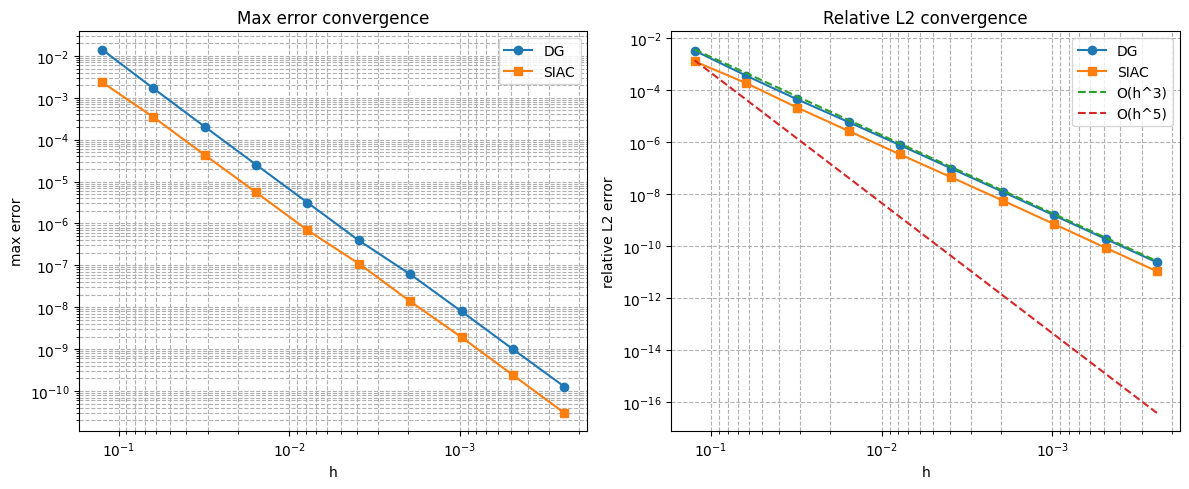

In [46]:
hs = results["h"]
Ks = results["K"]

dg_max = results["dg_max"]
siac_max = results["siac_max"]

dg_rel_l2 = results["dg_rel_l2"]
siac_rel_l2 = results["siac_rel_l2"]

# Extract
hs = results["h"]

dg_max = results["dg_max"]
siac_max = results["siac_max"]

dg_rel_l2 = results["dg_rel_l2"]
siac_rel_l2 = results["siac_rel_l2"]

# -------------------------
# Helper: compute slopes
# -------------------------
def compute_rates(h, err):
    rates = np.log(err[:-1] / err[1:]) / np.log(h[:-1] / h[1:])
    return rates

dg_rates = compute_rates(hs, dg_rel_l2)
siac_rates = compute_rates(hs, siac_rel_l2)

print("DG rates   :", dg_rates)
print("SIAC rates :", siac_rates)


# -------------------------
# Plot
# -------------------------
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# --- Max error ---
axs[0].loglog(hs, dg_max, "o-", label="DG")
axs[0].loglog(hs, siac_max, "s-", label="SIAC")

axs[0].set_xlabel("h")
axs[0].set_ylabel("max error")
axs[0].set_title("Max error convergence")
axs[0].grid(True, which="both", ls="--")
axs[0].legend()

# --- Relative L2 ---
axs[1].loglog(hs, dg_rel_l2, "o-", label="DG")
axs[1].loglog(hs, siac_rel_l2, "s-", label="SIAC")

axs[1].set_xlabel("h")
axs[1].set_ylabel("relative L2 error")
axs[1].set_title("Relative L2 convergence")
axs[1].grid(True, which="both", ls="--")
axs[1].legend()

def add_reference_line(ax, h, err, order, label):
    c = 1.1*err[0] / (h[0]**order)
    ax.loglog(h, c * h**order, "--", label=label)

# expected DG order ~ p+1, SIAC ~ 2p+1 (roughly)

add_reference_line(axs[1], hs, dg_rel_l2, p+1, f"O(h^{p+1})")
add_reference_line(axs[1], hs, siac_rel_l2, 2*p+1, f"O(h^{2*p+1})")

axs[1].legend()

axs[0].invert_xaxis()
axs[1].invert_xaxis()
plt.tight_layout()
plt.show()

